<a href="https://colab.research.google.com/github/tsilva/aiml-notebooks/blob/main/misc/wip-gymnasium-temporal-autoencoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Train Gymnasium with Convolutional Autoencoders with a Bottleneck

- TODO: add image resizing support
- TODO: add validation size
- TODO: train classifier
- TODO: run classifier

## Setup

Install non-optional packages:

In [1]:
!pip install wandb datasets pytorch_msssim tsilva_notebook_utils==0.0.24 > /dev/null

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.2 requires fsspec==2025.3.2, but you have fsspec 2024.12.0 which is incompatible.


🔑 Loading API keys and authentication tokens from Colab secrets:

In [2]:
from tsilva_notebook_utils.colab import load_secrets_into_env

load_secrets_into_env([
    'WANDB_API_KEY',
    'NOTIFICATION_URL',
    'NOTIFICATION_AUTH_TOKEN'
])

Define configuration:

In [49]:
import os
from tsilva_notebook_utils.colab import notebook_id_from_title

def setup_config():
    # @markdown ### 🏋️ Notebook Settings

    # @markdown Random seed for reproducibility
    seed = 42  # @param {type: "integer"}

    # @markdown ### 🗂️ Dataset Settings

    # @markdown Dataset ID
    dataset_id = "tsilva/GymnasiumRecording__SuperMarioBros_Nes"  # @param {type: "string"}

    # @markdown Frame stack size
    frame_stack_size = 4  # @param {type: "number"}

    image_scale = 0.5 # @param {type: "number"}

    # @markdown Convert frames to grayscale before training
    convert_to_grayscale = True  # @param {type: "boolean"}

    # @markdown Noise factor for input corruption
    noise_factor = 0  # @param {type: "number"}

    # @markdown ### 🧠 Model Settings

    # @markdown Latent space dimensionality
    latent_dim = 2048  # @param {type: "number"}

    # @markdown ### 🏋️ Training Settings

    # @markdown Number of training epochs
    n_epochs = 1000  # @param {type: "integer"}

    # @markdown Batch size
    batch_size = 128  # @param {type: "integer"}

    # @markdown Gradient clipping norm (0 = disabled)
    max_grad_norm = 0  # @param {type: "number"}

    # @markdown Weight decay for regularization
    weight_decay = 0  # @param {type: "number"}

    # @markdown Warmup ratio for learning rate scheduler
    warmup_ratio = 0  # @param {type: "number"}

    # @markdown Loss function to use
    loss_function = "mse"  # @param ["mse", "ssim"]

    # @markdown Learning rate for the optimizer
    learning_rate = 0.001  # @param {type: "number"}

    os.environ["NOTEBOOK_ID"] = "test"  # or notebook_id_from_title()

    return dict(
        # Notebook settings
        seed=seed,

        # Dataset
        dataset_id=dataset_id,
        frame_stack_size=frame_stack_size,
        image_scale=image_scale,
        convert_to_grayscale=convert_to_grayscale,
        noise_factor=noise_factor,

        # Model
        latent_dim=latent_dim,

        # Training
        n_epochs=n_epochs,
        batch_size=batch_size,
        max_grad_norm=max_grad_norm,
        weight_decay=weight_decay,
        warmup_ratio=warmup_ratio,
        loss_function=loss_function,
        learning_rate=learning_rate
    )

CONFIG = setup_config()

Load dataset:

In [4]:
from datasets import load_dataset
dataset = load_dataset(CONFIG["dataset_id"], split="train")

README.md:   0%|          | 0.00/382 [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/6.20M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3025 [00:00<?, ? examples/s]

Show sample dataset image:

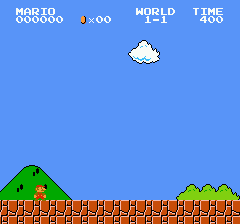

In [5]:
sample_image = dataset["image"][0]
sample_image

Convert image to grayscale:

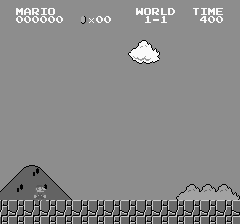

In [6]:
grayscale_image = sample_image.convert("L")
if CONFIG["convert_to_grayscale"]: sample_image = grayscale_image
sample_image

Downscale image:

In [ ]:
grayscale_image = sample_image.convert("L")
if CONFIG["convert_to_grayscale"]: sample_image = grayscale_image
sample_image

Convert dataset image to normalized tensor:

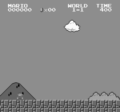

In [39]:
from torchvision.transforms.functional import to_tensor, resize
sample_image_t = to_tensor(sample_image)
image_height, image_width = sample_image_t.shape[1], sample_image_t.shape[2]
image_scale = CONFIG["image_scale"]
resized_tensor = resize(sample_image_t, [int(image_height * image_scale), int(image_width * image_scale)])
sample_image = to_pil_image(resized_tensor)
sample_image

In [40]:
from torchvision.transforms.functional import to_tensor
sample_image_t = to_tensor(sample_image)

Retrieve dataset image dimensions:

In [41]:
n_channels, image_height, image_width = sample_image_t.shape

Create the model:

In [42]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
from datasets import load_dataset

class ConvAutoencoder(nn.Module):
    def __init__(self, input_channels, output_channels, input_height, input_width, latent_dim=None):
        super(ConvAutoencoder, self).__init__()

        if latent_dim is None: latent_dim = CONFIG['latent_dim']

        # --- Encoder ---
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(input_channels, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        with torch.no_grad():
            dummy_input = torch.zeros(1, input_channels, input_height, input_width)
            dummy_output = self.encoder_conv(dummy_input)
            self._flattened_size = dummy_output.numel()
            self._conv_output_shape = dummy_output.shape[1:]

        self.fc_enc = nn.Linear(self._flattened_size, latent_dim)
        self.fc_dec = nn.Linear(latent_dim, self._flattened_size)

        # --- Decoder ---
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 2, stride=2),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, 2, stride=2),
            nn.ReLU(),

            nn.ConvTranspose2d(32, output_channels, 2, stride=2),
            nn.Sigmoid()
        )

    def encode(self, x):
        x = self.encoder_conv(x)
        x = x.view(x.size(0), -1)     # Flatten
        z = self.fc_enc(x)            # Latent vector
        return z

    def decode(self, z):
        x = self.fc_dec(z)
        x = x.view(z.size(0), *self._conv_output_shape)  # Reshape to conv output
        x = self.decoder_conv(x)
        return x

    def forward(self, x):
        z = self.encode(x)
        out = self.decode(z)
        return out

model = ConvAutoencoder(CONFIG["frame_stack_size"] * n_channels, 1, image_height, image_width)
model

ConvAutoencoder(
  (encoder_conv): Sequential(
    (0): Conv2d(4, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_enc): Linear(in_features=26880, out_features=2048, bias=True)
  (fc_dec): Linear(in_features=2048, out_features=26880, bias=True)
  (decoder_conv): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(2, 2), stride=(2, 2))
    (1): ReLU()
    (2): ConvTranspose2d(64, 32, kernel_size=(2, 2), stride=(2, 2))
    (3): ReLU()
    (4): ConvTranspose2d(32, 1, kernel_size=(2, 2), stride=(2, 2))
    (5): Sigmoid()
  )

Let's check how much compression the encoder is providing, first let's check how many parameters are currently required to encode a sample image:

In [43]:
sample_image_t.shape, sample_image_t.numel()

(torch.Size([1, 112, 120]), 13440)

Now let's check how many are required to represent a reconstructed picture:

In [20]:
#stack_t = torch.cat([sample_image_t.squeeze()] * CONFIG['frame_stack_size'])
#encoded_t = model.encode(stack_t)
#encoded_t.shape, encoded_t.numel()

Assert that the encoded dimensions match the configured latent dimension:

In [21]:
#latent_dim = encoded_t.numel()
#assert latent_dim == CONFIG['latent_dim']

NameError: name 'encoded_t' is not defined

And now we can calculate how much compression we're getting:

In [ ]:
#compression = latent_dim / sample_image_t.numel()
#print(f"Compression: {compression * 100:.2f}% of original size")

Check what image with noise looks like:

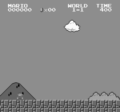

In [44]:
noisy_sample_image_t = sample_image_t + torch.randn_like(sample_image_t) * CONFIG['noise_factor']
to_pil = transforms.ToPILImage()
noisy_sample_image = to_pil(noisy_sample_image_t)
noisy_sample_image

Let's process dataset to ensure it has configured transformations (eg: grayscaling and image noise):

In [45]:
import torch
import multiprocessing
from torchvision.transforms.functional import to_tensor, to_pil_image
from PIL import Image

def _map_batch(batch):
    if CONFIG['convert_to_grayscale']:
        images = [img.convert("L") for img in batch["image"]]
    else:
        images = batch["image"]

    image_ts = [to_tensor(img) for img in images]

    noise = torch.randn_like(torch.stack(image_ts)) * CONFIG["noise_factor"]
    noisy_ts = torch.clamp(torch.stack(image_ts) + noise, 0.0, 1.0)

    inputs = [to_pil_image(noisy) for noisy in noisy_ts]
    targets = [to_pil_image(orig) for orig in image_ts]

    # Resize both inputs and targets
    scale = CONFIG["image_scale"]
    if isinstance(scale, (int, float)):
        inputs = [img.resize((int(img.width * scale), int(img.height * scale)), Image.BILINEAR) for img in inputs]
        targets = [img.resize((int(img.width * scale), int(img.height * scale)), Image.BILINEAR) for img in targets]

    return dict(
        input=inputs,
        target=targets
    )

dataset = dataset.map(
    _map_batch,
    batched=True,
    batch_size=64,
    num_proc=multiprocessing.cpu_count()
)

Map (num_proc=2):   0%|          | 0/3025 [00:00<?, ? examples/s]

Render video with procssed images to double check that noise level is appropriate:

In [46]:
import tempfile
from tsilva_notebook_utils.video import save_frames_to_dir, render_loader_video

def collate_fn(batch): return (torch.stack([to_tensor(x["input"]) for x in batch]), torch.stack([to_tensor(x["target"]) for x in batch]))
loader = DataLoader(dataset, batch_size=CONFIG["batch_size"], shuffle=False, collate_fn=collate_fn)
render_loader_video(loader)

Rendering frames: 100%|██████████| 24/24 [00:04<00:00,  5.22it/s]


Create model, loss function and optimizer:

In [50]:
from tsilva_notebook_utils.torch import get_current_device

device = get_current_device()
model = ConvAutoencoder(CONFIG['frame_stack_size'] * n_channels, 1, image_height, image_width).to(device)

if CONFIG['loss_function'] == 'mse':
    loss_fn = nn.MSELoss()
elif CONFIG['loss_function'] == 'ssim':
    from pytorch_msssim import MS_SSIM
    ms_ssim = MS_SSIM(data_range=1.0, size_average=True, channel=n_channels)
    loss_fn = lambda pred, target: 1 - ms_ssim(pred, target)

optimizer = optim.Adam(model.parameters(), lr=CONFIG["learning_rate"], weight_decay=CONFIG["weight_decay"])

Create train data loader that stacks N frames as X, and puts N + 1 frame in Y:

In [51]:
import torch
from torchvision.transforms.functional import to_tensor

class PredictiveFrameCollator:
    def __init__(self, stack_size=4):
        self.stack_size = stack_size

    def __call__(self, batch):
        # Convert all images to tensors first
        inputs = [to_tensor(sample["input"]) for sample in batch]
        targets = [to_tensor(sample["target"]) for sample in batch]

        X = []
        Y = []

        # Make sure there's enough to stack
        for i in range(len(inputs) - self.stack_size):
            stacked_input = torch.cat(inputs[i:i + self.stack_size], dim=0)  # Shape: (stack_size * C, H, W)
            target = targets[i + self.stack_size]  # The frame after the stack

            X.append(stacked_input)
            Y.append(target)

        if not X:
            return None  # or throw an error, depending on your needs

        return torch.stack(X), torch.stack(Y)

stack_collator = PredictiveFrameCollator(stack_size=CONFIG["frame_stack_size"])
train_loader = DataLoader(
    dataset,
    batch_size=CONFIG["batch_size"],  # or whatever fits your memory
    shuffle=True,
    collate_fn=stack_collator
)
model.eval()
for x, y in train_loader:
  x = x.to(device)
  y = y.to(device)
  print(x.shape)
  print(y.shape)
  with torch.no_grad(): y_pred = model(x)
  print(y_pred.shape)
  loss = loss_fn(y_pred, y)
  print(loss.item())
  break

torch.Size([124, 4, 112, 120])
torch.Size([124, 1, 112, 120])
torch.Size([124, 1, 112, 120])
0.04016490653157234


📈 Initializing Weights & Biases (wandb) for experiment tracking:


In [52]:
from tsilva_notebook_utils.wandb import init_with_defaults
init_with_defaults(CONFIG)

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


grad/layer/decoder_conv.0.bias,▇▇▇▅▄▃█▆▆▂▅▁▂▃
grad/layer/decoder_conv.0.weight,█▄▇▂▃▂▂▄▂▂▁▁▁▁
grad/layer/decoder_conv.2.bias,▄█▄▄▃▂▃▂█▁▂▁▂▂
grad/layer/decoder_conv.2.weight,▇▃█▁▂▃▃▅▄▅▂▁▂▃
grad/layer/decoder_conv.4.bias,█▅▁▄█▁▁▁▅█▂▄▄▁
grad/layer/decoder_conv.4.weight,▆▂█▂▂▃▄▆▅▆▃▁▂▄
grad/layer/encoder_conv.0.bias,█▁▇▂▁▁▅▁▃▂▁▁▁▁
grad/layer/encoder_conv.0.weight,█▁▇▂▁▂▅▁▂▂▁▁▁▁
grad/layer/encoder_conv.3.bias,█▁█▂▁▁▅▂▄▂▂▃▂▂
grad/layer/encoder_conv.3.weight,█▁▇▁▁▁▄▁▂▂▁▂▁▁
grad/layer/encoder_conv.6.bias,▆▁█▂▁▁█▃▅▄▄▄▄▆


Run training:

In [53]:
import wandb
from tqdm import tqdm
import torch.optim as optim
from torch.nn.utils import clip_grad_norm_
from tsilva_notebook_utils.torch import calc_model_grad_norms

# TODO: is calculating grad norms slow?
def train(
    model,
    loss_fn,
    optimizer,
    train_loader,
    n_epochs=None,
    eval_fn=None,
    learning_rate=None,
    max_grad_norm=None,
    warmup_ratio=None
):
    if n_epochs is None: n_epochs = CONFIG['n_epochs']
    if learning_rate is None: learning_rate = CONFIG['learning_rate']
    if max_grad_norm is None: max_grad_norm = CONFIG['max_grad_norm']
    if warmup_ratio is None: warmup_ratio = CONFIG['warmup_ratio']

    # Set model to training mode
    model.train()

    # Watch model for gradient logging with wandb
    wandb.watch(model, log="all")

    # Linear warmup schedule: linearly increase LR for warmup_steps, then keep constant
    total_steps = n_epochs * len(train_loader)
    warmup_steps = int(warmup_ratio * total_steps) if warmup_ratio else 0
    def lr_lambda(current_step): return float(current_step) / float(max(1, warmup_steps)) if current_step < warmup_steps else 1.0
    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)

    # Progress bar for training
    global_step = 0
    device = next(model.parameters()).device
    with tqdm(range(n_epochs), desc="Training") as pbar:
        for epoch in pbar:
            losses, accuracies, grad_norms, layer_norms = [], [], [], {}
            last_layer_norms = {}

            # Iterate over batches
            for x_batch, y_batch in train_loader:
                x_batch = x_batch.to(device)
                y_batch = y_batch.to(device)

                global_step += 1

                # Forward pass
                logits = model(x_batch)

                # Calculate loss
                loss = loss_fn(logits, y_batch)

                losses.append(loss.item())

                # Perform backpropagation
                optimizer.zero_grad()
                loss.backward()

                # Optionally clip gradients to avoid exploding gradients
                if max_grad_norm: clip_grad_norm_(model.parameters(), max_grad_norm)

                # Calculate gradient norms for monitoring
                _grad_norm, _layer_norms = calc_model_grad_norms(model)
                grad_norms.append(_grad_norm)

                last_layer_norms = layer_norms

                # Perform optimization step
                optimizer.step()

                # Perform learning rate scheduler step
                scheduler.step()

                # Calculate training accuracy
                #with torch.no_grad():
                #    predicted = torch.argmax(logits, dim=1)
                #    accuracy = (predicted == y_batch).float().mean().item()
                #    accuracies.append(accuracy)

            # Log W&B stats
            train_loss = sum(losses) / len(losses)
            #train_accuracy = sum(accuracies) / len(accuracies)
            train_grad_norm = sum(grad_norms) / len(grad_norms)
            current_lr = scheduler.get_last_lr()[0]
            wandb_stats = {
                'meta/epoch': epoch + 1,
                'meta/step': global_step,
                'meta/learning_rate': current_lr,

                'train/loss': train_loss,
                #'train/accuracy': train_accuracy,

                'grad/total_norm': train_grad_norm,
            }
            for _layer_name, _layer_norm in _layer_norms.items(): wandb_stats[f'grad/layer/{_layer_name}'] = _layer_norm

            pbar_stats = {
                'epoch': epoch + 1,
                'train_loss': f'{train_loss:.4f}',
                'lr': f'{current_lr:.6e}',
                #'grad_norm': f'{train_grad_norm:.2f}',
                #'train_acc': f'{train_accuracy * 100:.2f}%'
            }

            # Run evaluation on validation set
            if eval_fn:
                result = eval_fn()
                val_loss = result['loss']
                val_accuracy = result['accuracy']
                wandb_stats['val/loss'] = val_loss
                wandb_stats['val/accuracy'] = val_accuracy
                pbar_stats['val_acc'] =  f'{val_accuracy * 100:.2f}%'

            # Log stats to w-andb
            wandb.log(wandb_stats, step=global_step)

            # Show key metrics in progress bar
            pbar.set_postfix(pbar_stats)

            # Early stopping if training accuracy hits 100%
            #if train_accuracy == 1.0:
            #    print("\nTraining finished early: model perfectly fit the training set.")
            #    break

    wandb.finish()

train(model, loss_fn, optimizer, train_loader)

Training:   0%|          | 2/1000 [00:15<2:08:54,  7.75s/it, epoch=2, train_loss=0.0394, lr=1.000000e-03]


KeyboardInterrupt: 

Render video of autoencoder predictions:

In [54]:
from tsilva_notebook_utils.video import render_autoencoder_video, render_video_from_dir

test_loader = DataLoader(
    dataset,
    batch_size=CONFIG["batch_size"],  # or whatever fits your memory
    shuffle=False,
    collate_fn=stack_collator
)
render_autoencoder_video(model, test_loader, compare_inputs=False)

100%|██████████| 24/24 [00:06<00:00,  3.62it/s]


⏰ Setting up auto-notification and resource management:

In [ ]:
from tsilva_notebook_utils.colab import notify_and_disconnect_after_timeout
notify_and_disconnect_after_timeout()